# 01 — Frontier orbital analysis

Compare HOMO/LUMO energies, HOMO-LUMO gaps, energy shifts, and frontier-orbital summary figures for parent and terminal-functionalized PDI.


In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
FMO_FIGURES = ROOT / "figures" / "orbitals"
FMO_FIGURES.mkdir(parents=True, exist_ok=True)

orbitals = pd.read_csv(
    RESULTS / "orbitals" / "frontier_orbital_energies.csv"
)

In [2]:
orbitals["gap_ev"] = (
    orbitals["lumo_energy_ev"]
    - orbitals["homo_energy_ev"]
)

In [3]:
orbitals[
    [
        "system",
        "homo_energy_ev",
        "lumo_energy_ev",
        "gap_ev",
    ]
]

,system,homo_energy_ev,lumo_energy_ev,gap_ev
0,pdi,-8.274638,-2.248267,6.026371
1,pdi_terminal_functionalized,-8.069103,-2.060670,6.008433


In [4]:
orbital_indexed = orbitals.set_index("system")

delta_homo = (
    orbital_indexed.loc[
        "pdi_terminal_functionalized",
        "homo_energy_ev",
    ]
    - orbital_indexed.loc["pdi", "homo_energy_ev"]
)

delta_lumo = (
    orbital_indexed.loc[
        "pdi_terminal_functionalized",
        "lumo_energy_ev",
    ]
    - orbital_indexed.loc["pdi", "lumo_energy_ev"]
)

delta_gap = (
    orbital_indexed.loc[
        "pdi_terminal_functionalized",
        "gap_ev",
    ]
    - orbital_indexed.loc["pdi", "gap_ev"]
)

## Frontier orbital plots

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
    }
)

SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Functionalized PDI",
}

SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}

DEFAULT_COLORS = ["#0018F9", "#F28500", "#6B7CDB", "#D08A3A", "#9AA0A6"]

FIGURE_BACKGROUND = "white"
AXIS_COLOR = "black"
GRID_COLOR = "#9AA0A6"

def display_label(row):
    label = SYSTEM_LABELS.get(row["system"], row["system"].replace("_", " ").title())
    if "spin_channel" in row and pd.notna(row["spin_channel"]) and str(row["spin_channel"]).strip():
        label = f"{label} ({row['spin_channel']})"
    return label

def color_for(system, index):
    return SYSTEM_COLORS.get(system, DEFAULT_COLORS[index % len(DEFAULT_COLORS)])

def practical_chemistry_axis(ax, xlabel=None, ylabel=None, title=None, legend=False, legend_loc="best"):
    fig = ax.figure
    fig.patch.set_facecolor(FIGURE_BACKGROUND)
    ax.set_facecolor(FIGURE_BACKGROUND)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_color(AXIS_COLOR)

    ax.tick_params(axis="both", labelsize=14, direction="in", width=1.4, colors=AXIS_COLOR)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(AXIS_COLOR)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if title:
        ax.set_title(title, fontsize=18, fontweight="bold", color=AXIS_COLOR)

    #ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.35, color=GRID_COLOR)

    if legend:
        legend_obj = ax.legend(loc=legend_loc, prop={"size": 12, "weight": "bold"})
        legend_obj.get_frame().set_facecolor(FIGURE_BACKGROUND)
        legend_obj.get_frame().set_edgecolor(AXIS_COLOR)
        for text in legend_obj.get_texts():
            text.set_color(AXIS_COLOR)

    return ax

frontier = orbitals.copy()
frontier["plot_label"] = frontier.apply(display_label, axis=1)
frontier["color"] = [color_for(system, i) for i, system in enumerate(frontier["system"])]
frontier

,system,homo_index,lumo_index,homo_energy_au,lumo_energy_au,homo_energy_ev,lumo_energy_ev,gap_ev,source_file,plot_label,color
0,pdi,100,101,-0.304087,-0.082622,-8.274638,-2.248267,6.026371,calculations/pdi/multiwfn_analysis/pdi_sp.mold...,Parent PDI,#0018F9
1,pdi_terminal_functionalized,140,141,-0.296534,-0.075728,-8.069103,-2.060670,6.008433,calculations/pdi_terminal_functionalized/multi...,Functionalized PDI,#F28500


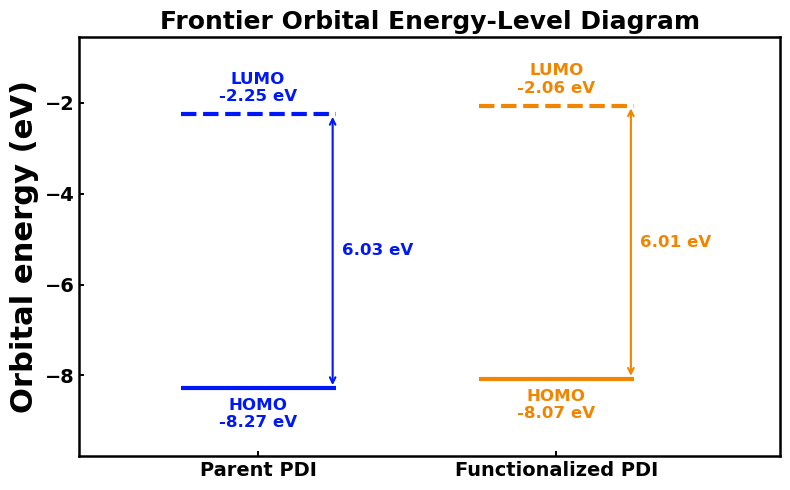

In [6]:
# Frontier orbital energy-level diagram
fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIGURE_BACKGROUND)
level_half_width = 0.26
x_positions = np.arange(len(frontier))

for x, (_, row) in zip(x_positions, frontier.iterrows()):
    color = row["color"]
    homo = row["homo_energy_ev"]
    lumo = row["lumo_energy_ev"]
    gap = row["gap_ev"]

    ax.hlines(homo, x - level_half_width, x + level_half_width, color=color, lw=3.0, label="HOMO" if x == 0 else None)
    ax.hlines(lumo, x - level_half_width, x + level_half_width, color=color, lw=3.0, linestyle="--", label="LUMO" if x == 0 else None)

    ax.annotate(
        "",
        xy=(x + 0.25, lumo),
        xytext=(x + 0.25, homo),
        arrowprops={"arrowstyle": "<->", "lw": 1.5, "color": color},
    )
    ax.text(
        x + 0.28,
        (homo + lumo) / 2,
        f"{gap:.2f} eV",
        va="center",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color=color,
    )
    ax.text(x, homo - 0.22, f"HOMO\n{homo:.2f} eV", ha="center", va="top", fontsize=12, fontweight="bold", color=color)
    ax.text(x, lumo + 0.22, f"LUMO\n{lumo:.2f} eV", ha="center", va="bottom", fontsize=12, fontweight="bold", color=color)

ax.set_xticks(x_positions)
ax.set_xticklabels(frontier["plot_label"], rotation=0, ha="center")
ax.set_xlim(-0.6, len(frontier) - 0.25)
y_min = frontier["homo_energy_ev"].min() - 1.5
y_max = frontier["lumo_energy_ev"].max() + 1.5
ax.set_ylim(y_min, y_max)
practical_chemistry_axis(
    ax,
    ylabel="Orbital energy (eV)",
    title="Frontier Orbital Energy-Level Diagram",
)
plt.tight_layout()

fig.savefig(
    FMO_FIGURES / "fmo_energy_level_diagram.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FMO_FIGURES / "fmo_energy_level_diagram.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()